# QAOA Example (MaxCut)

这里展示如何使用 `cqlib-qaoa` 中的 QAOA 求解 MaxCut 问题。

In [2]:
from cqlib_qaoa.problems.maxcut import MaxCut
from cqlib_qaoa.mappings.convert import maxcut_to_qubo, qubo_to_ising
from cqlib_qaoa.visualization.maxcut_plot import plot_maxcut
from cqlib_qaoa.execution import LocalRunner, TianYanRunner
from cqlib_qaoa.algorithms.qaoa import QAOASolver, QAOAConfig
from cqlib_qaoa.optimizers.options import OptimizerOptions

print("Imports ready")

Imports ready


## 1. 定义 MaxCut 实例

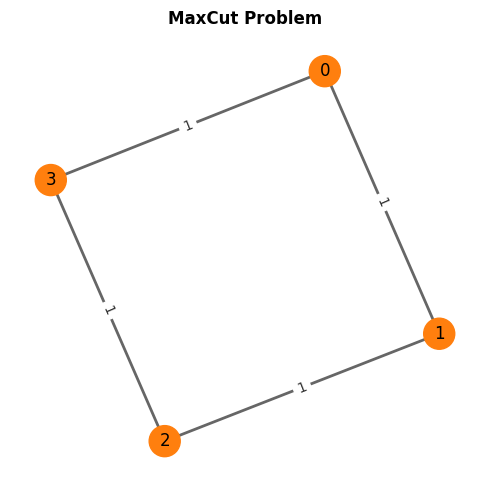

In [3]:
weights = {(0, 1): 1, (1, 2): 1, (2, 3): 1, (3, 0): 1}
mc = MaxCut(n=4, weights=weights)
plot_maxcut(n=mc.n, weights=mc.weights, partition={}, title="MaxCut Problem")

## 2. MaxCut → QUBO

In [4]:
qubo = maxcut_to_qubo(mc)
print(qubo)

========== [ QUBO ] ==========
Maximize: - 2*x_0*x_1 - 2*x_0*x_3 - 2*x_1*x_2 - 2*x_2*x_3 + 2*x_0 + 2*x_1 + 2*x_2 + 2*x_3



## 3. QUBO → Ising

In [5]:
ising = qubo_to_ising(qubo)
print(ising)

========== [ Ising Hamiltonian ] ==========
Paulis = ['IIZZ', 'ZIIZ', 'IZZI', 'ZZII'],
coeffs = [0.500, 0.500, 0.500, 0.500]
offset = -2.000



## 4. 运行 QAOA（LocalRunner）

In [6]:
opt_cfg = OptimizerOptions(name="spsa", options={"maxiter": 1000})
solver = QAOASolver(
    ising, runner=LocalRunner(), qaoa_cfg=QAOAConfig(reps=3, mixer="x"), opt_cfg=opt_cfg
)
res = solver.run()

[iter=  1] f=-1.944 theta=[-0.458, -0.458, 2.058, -1.058, -1.058, 1.458]
[iter=  2] f=-2.170 theta=[-0.322, -0.594, 1.922, -0.922, -1.194, 1.322]
[iter=  3] f=-1.478 theta=[0.193, -1.109, 2.437, -0.407, -1.709, 1.837]
[iter=  4] f=-2.410 theta=[0.427, -0.876, 2.670, -0.640, -1.476, 2.070]
[iter=  5] f=-2.572 theta=[0.448, -0.855, 2.691, -0.661, -1.455, 2.091]
[iter=  6] f=-2.558 theta=[0.526, -0.777, 2.613, -0.583, -1.533, 2.013]
[iter=  7] f=-2.506 theta=[0.521, -0.772, 2.619, -0.589, -1.527, 2.019]
[iter=  8] f=-1.602 theta=[0.817, -0.475, 2.915, -0.292, -1.231, 1.722]
[iter=  9] f=-3.104 theta=[0.639, -0.297, 3.093, -0.471, -1.409, 1.544]
[iter= 10] f=-3.078 theta=[0.639, -0.297, 3.093, -0.471, -1.409, 1.544]
[iter= 11] f=-3.080 theta=[0.615, -0.274, 3.116, -0.494, -1.432, 1.521]
[iter= 12] f=-3.116 theta=[0.673, -0.332, 3.174, -0.552, -1.490, 1.579]
[iter= 13] f=-3.084 theta=[0.645, -0.360, 3.146, -0.523, -1.519, 1.607]
[iter= 14] f=-3.124 theta=[0.633, -0.372, 3.158, -0.511, -1.53

## 5. 可视化：运行结果

In [7]:
res.print_result()


========== [ Experiment Information ] ==========
Task ID  : 20260723110036
Shots  : 1000

========== [ Optimize Configs ] ==========
runner      : LocalRunner
qaoa_cfg    : {'reps': 3, 'mixer': 'x', 'shots': 1000, 'name': 'QAOA', 'wrap_angles': True, 'need_transpile': None, 'verbose': True}
opt_cfg    : {'name': 'spsa', 'options': {'maxiter': 1000}}

========== [ Measurement Results ] ==========
probability : {'0101': 0.516, '1010': 0.479, '0100': 0.002, '0011': 0.001, '0110': 0.001, '0111': 0.001}


## 6. 可视化：迭代曲线与概率分布

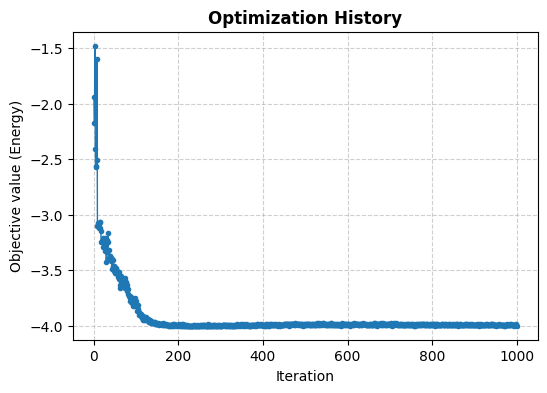

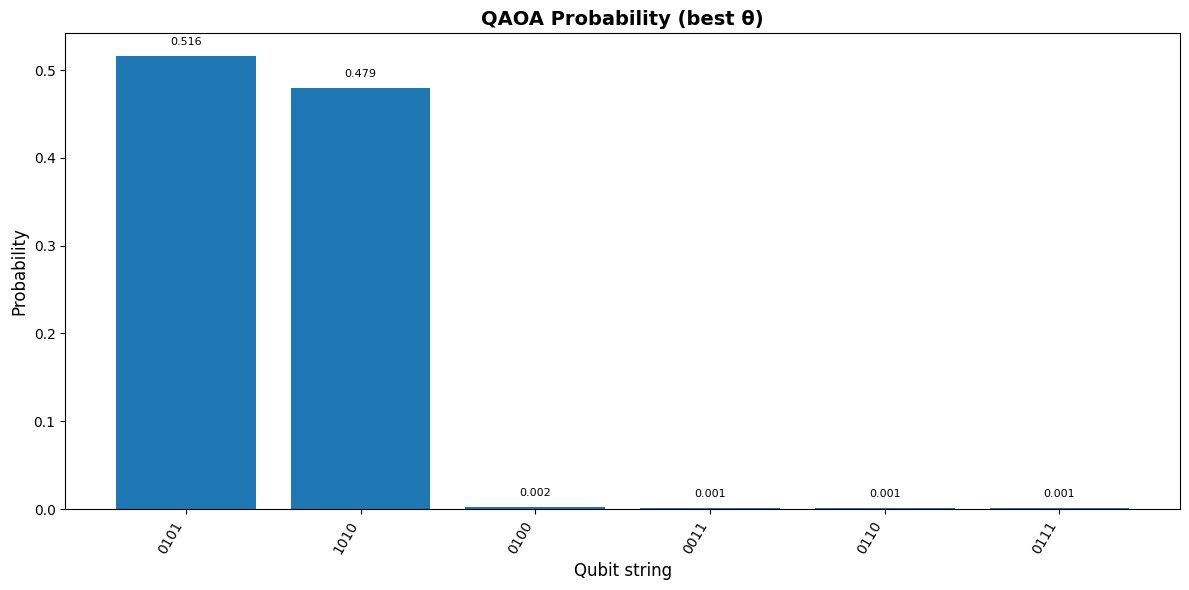

In [8]:
res.plot_history(title="Optimization History")
res.plot_probability(title="QAOA Probability (best θ)", topk=20)

## 7. 可视化：最优 MaxCut 解


========== [ Optimization Results ] ==========
Best gammas : [1.663, -0.823, 3.081]
Best betas  : [-1.192, -0.986, 1.780]
Best energy : -3.998
Best Qubit string:  0101
Best solution: [1, 3]
Max-Cut value: 4.000


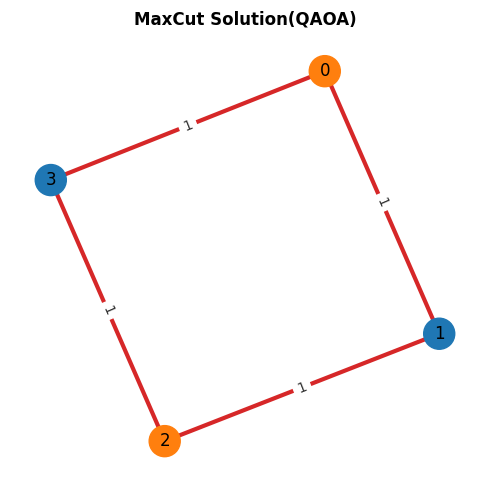

[1, 3]

In [9]:
res.plot_maxcut_solution(n=mc.n, weights=mc.weights, title="MaxCut Solution(QAOA)")

### 可选：对接中电信“天衍”量子计算云平台后端
将 `LocalRunner()` 替换为 `TianYanRunner()`：
```python
from cqlib_qaoa.execution import TianYanRunner
runner = TianYanRunner(login_key='YOUR_KEY', machine='tianyan_sw')
```
